# 付録. 演習解答

各章(01〜07)の演習の解答(コード + 短い解説)です。**まず自力で試してから** 参照してください。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

from la_book import algebra, datasets, decompositions as dec, plotting

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 01 章の解答

### 演習 1 — ベクトルの足し算・スカラー倍

v + w  = [1. 4.]   (hand: (1, 4))
2v - w = [ 5. -1.]   (hand: (5, -1))


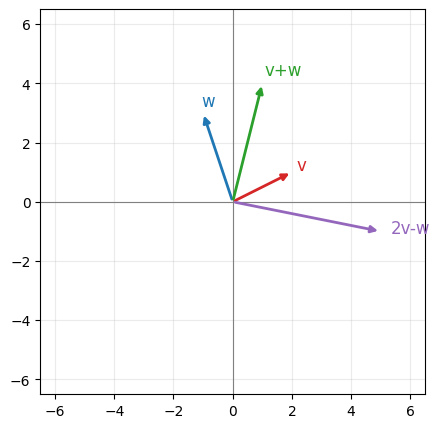

In [2]:
v = np.array([2.0, 1.0]); w = np.array([-1.0, 3.0])
print("v + w  =", v + w, "  (hand: (1, 4))")
print("2v - w =", 2 * v - w, "  (hand: (5, -1))")
plotting.plot_vectors([v, w, v + w, 2 * v - w], labels=["v", "w", "v+w", "2v-w"])
plt.show()

### 演習 2 — 90° 回転行列

$e_1 = (1,0) \to (0,1)$, $e_2 = (0,1) \to (-1,0)$ なので、その行き先を列に並べて
$R_{90} = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}$。

R90 @ e1 = [0. 1.]  R90 @ e2 = [-1.  0.]


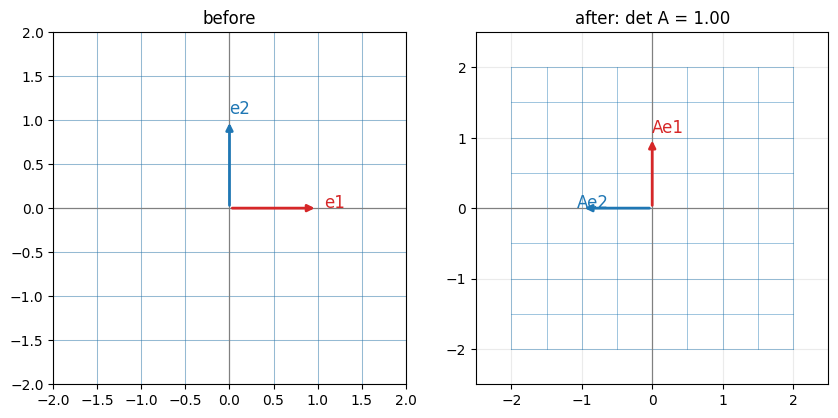

In [3]:
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])
print("R90 @ e1 =", R90 @ [1, 0], " R90 @ e2 =", R90 @ [0, 1])
plotting.plot_grid_transform(R90)
plt.show()

### 演習 3 — 鏡映の行列式

$x$ 軸鏡映 $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ の行列式は $-1$。
負なのは「向き(時計回り/反時計回り)が反転する」ため。面積の倍率は $|{-1}| = 1$ で変わらない。

det = -1.0  (negative = orientation flipped)


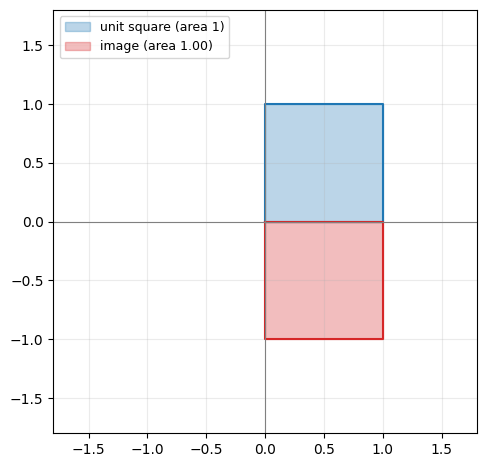

In [4]:
M = np.array([[1.0, 0.0], [0.0, -1.0]])
print("det =", np.linalg.det(M), " (negative = orientation flipped)")
plotting.plot_unit_square(M)
plt.show()

### 演習 4 — 合成の非可換性($R_{90}S$ vs $SR_{90}$)

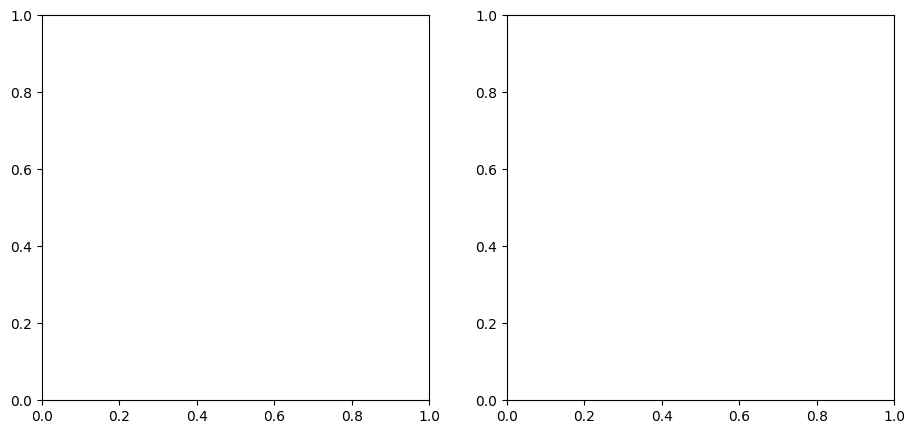

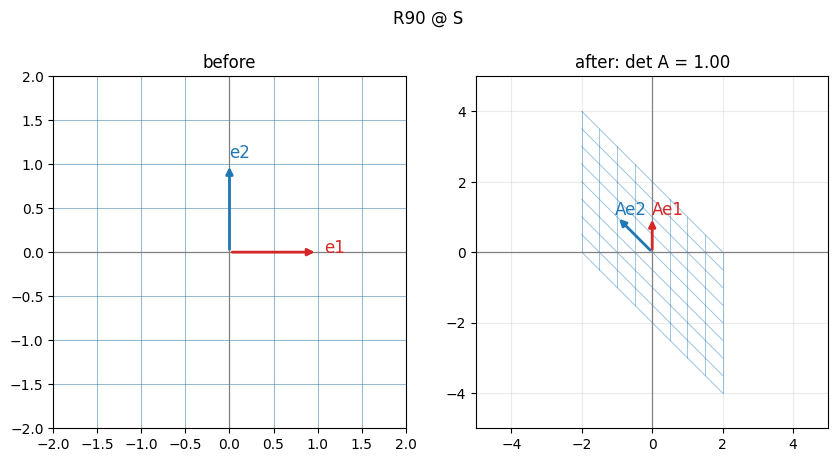

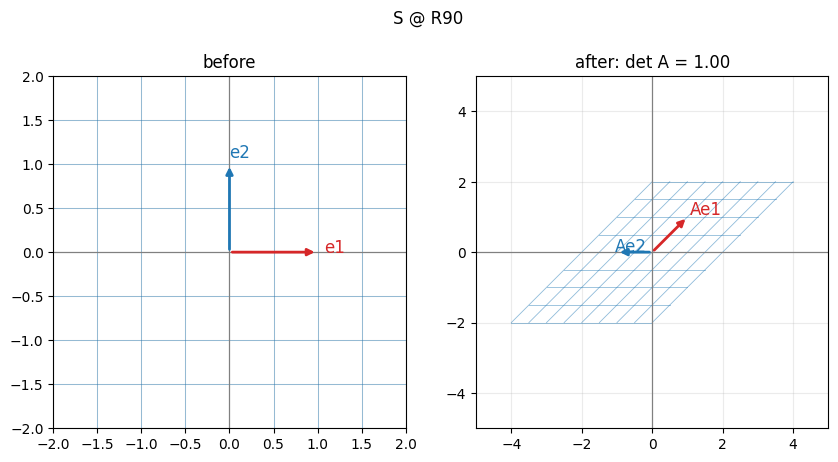

R90@S == S@R90 ? False


In [5]:
S = np.array([[1.0, 1.0], [0.0, 1.0]])
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plotting.plot_grid_transform(R90 @ S, axes=[axes[0], axes[0]]) if False else None
plotting.plot_grid_transform(R90 @ S)
plt.suptitle("R90 @ S")
plt.show()
plotting.plot_grid_transform(S @ R90)
plt.suptitle("S @ R90")
plt.show()
print("R90@S == S@R90 ?", np.allclose(R90 @ S, S @ R90))

### 演習 5 — 列が同一直線上 → つぶれる($\det = 0$)

det = 0.0


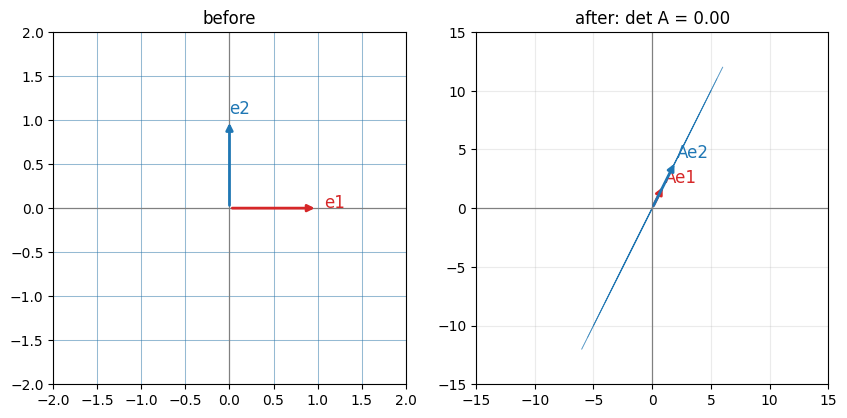

In [6]:
D = np.array([[1.0, 2.0], [2.0, 4.0]])   # col2 = 2*col1
print("det =", np.linalg.det(D))
plotting.plot_grid_transform(D)
plt.show()

### 演習 6(発展)— 3D 回転と立方体

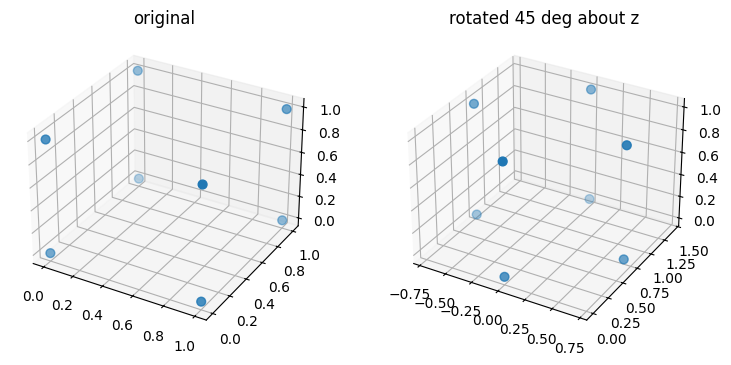

In [7]:
t = np.pi / 4
Rz = np.array([[np.cos(t), -np.sin(t), 0], [np.sin(t), np.cos(t), 0], [0, 0, 1.0]])
cube = np.array([[x, y, z] for x in (0, 1) for y in (0, 1) for z in (0, 1)], dtype=float)
rot = cube @ Rz.T
fig = plt.figure(figsize=(9, 4))
for i, (pts, name) in enumerate([(cube, "original"), (rot, "rotated 45 deg about z")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.scatter(*pts.T, s=40)
    ax.set_title(name)
plt.show()

## 02 章の解答

### 演習 1 — 連立方程式を掃き出しで解く

$x + 2y = 5,\ 3x - y = 1 \Rightarrow x = 1,\ y = 2$。

In [8]:
Ab = np.array([[1.0, 2.0, 5.0], [3.0, -1.0, 1.0]])
R, piv = algebra.rref(Ab)
print("RREF:\n", R, "\n-> x =", R[0, 2], ", y =", R[1, 2])

RREF:
 [[1. 0. 1.]
 [0. 1. 2.]] 
-> x = 1.0 , y = 2.0


### 演習 2 — 解なし / 解が無限 の RREF

最終行が `[0 0 | 1]`(矛盾)なら解なし、`[0 0 | 0]`(自由変数)なら解が無限。

In [9]:
for name, Ab in [("no solution", np.array([[1.0, 2, 3], [2, 4, 5]])),
                 ("infinite", np.array([[1.0, 2, 3], [2, 4, 6]]))]:
    R, piv = algebra.rref(Ab)
    print(f"{name}: RREF last row = {R[-1]}")

no solution: RREF last row = [0. 0. 1.]
infinite: RREF last row = [0. 0. 0.]


### 演習 3 — ランク・核・像

In [10]:
A = np.array([[1.0, 2, 3], [2, 4, 6], [1, 1, 1]])
print("rank =", algebra.rank(A))
print("kernel basis:", [list(v) for v in sp.Matrix(A).nullspace()])
# Image basis = pivot columns of the ORIGINAL matrix.
R, piv = algebra.rref(A)
print("pivot columns:", piv, "-> image basis = original columns", piv)

rank = 2
kernel basis: [[1.00000000000000, -2.00000000000000, 1]]
pivot columns: [0, 1] -> image basis = original columns [0, 1]


### 演習 4 — ランク 1 行列は点群を直線につぶす

rank = 1


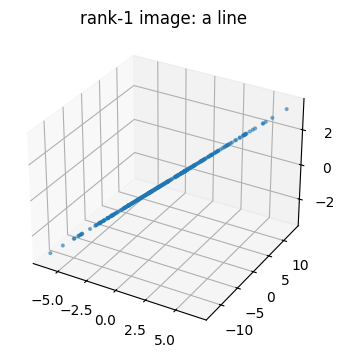

In [11]:
M1 = np.outer([1.0, 2.0, 0.5], [1.0, -1.0, 2.0])   # rank 1
print("rank =", np.linalg.matrix_rank(M1))
cloud = rng.standard_normal((300, 3))
out = cloud @ M1.T
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*out.T, s=4, alpha=0.5)
ax.set_title("rank-1 image: a line")
plt.show()

### 演習 5 — Vandermonde で 3 次多項式

coefficients (c0..c3): [1. 0. 1. 0.]


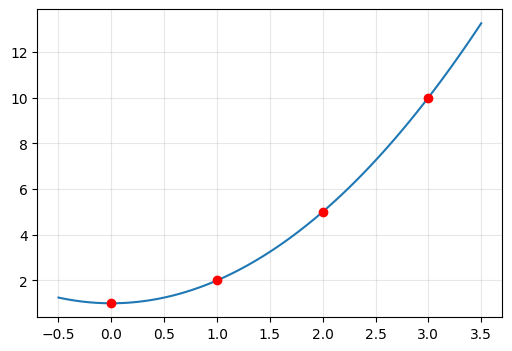

In [12]:
xs = np.array([0.0, 1, 2, 3]); ys = np.array([1.0, 2, 5, 10])
V = np.vander(xs, 4, increasing=True)
coef = np.linalg.solve(V, ys)
print("coefficients (c0..c3):", coef)
xx = np.linspace(-0.5, 3.5, 100)
plt.figure(figsize=(6, 4))
plt.plot(xx, sum(coef[i] * xx**i for i in range(4)))
plt.scatter(xs, ys, color="red", zorder=3)
plt.grid(alpha=0.3); plt.show()

### 演習 6(発展)— $m < n$ では一意解はあり得ない

次元定理 $\dim(\mathrm{Ker}\,A) + \mathrm{rank}\,A = n$。$A$ は $m \times n$ で $\mathrm{rank}\,A \le m < n$ なので
$\dim(\mathrm{Ker}\,A) = n - \mathrm{rank}\,A \ge n - m > 0$。核が非自明 → 解があれば「特殊解 + 核」で無限個。よって一意解はあり得ない。

## 03 章の解答

### 演習 1 — 対角行列の固有値・固有ベクトル

対角行列の固有値は対角成分そのもの(3, 0.5)、固有ベクトルは軸 $e_1, e_2$。

eigenvalues: [3.  0.5]


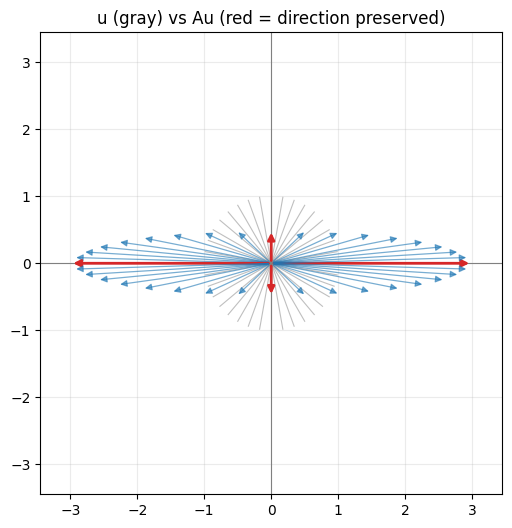

In [13]:
A = np.array([[3.0, 0.0], [0.0, 0.5]])
w, V = np.linalg.eig(A)
print("eigenvalues:", w)
plotting.plot_direction_field(A)
plt.show()

### 演習 2 — 特性方程式

$\det(A - \lambda I) = (2-\lambda)^2 - 1 = \lambda^2 - 4\lambda + 3 = (\lambda-1)(\lambda-3)$ → 固有値 1, 3。

In [14]:
lam = sp.symbols("lamda")
charpoly = sp.Matrix([[2, 1], [1, 2]]).charpoly(lam).as_expr()
print("char poly:", sp.factor(charpoly), "-> roots", sp.solve(charpoly, lam))
print("numpy:", np.linalg.eigvals(np.array([[2.0, 1], [1, 2]])))

char poly: (lamda - 3)*(lamda - 1) -> roots [1, 3]
numpy: [3. 1.]


### 演習 3 — 固有成分の幾何級数的減衰

In [15]:
P = np.array([[0.9, 0.2], [0.1, 0.8]])
w, V = np.linalg.eig(P)
x0 = np.array([50.0, 50.0])
coords0 = np.linalg.solve(V, x0)        # components in the eigenbasis
for k in [0, 1, 2, 5, 10]:
    coords = coords0 * w**k
    print(f"k={k:>2}: lambda=0.7 component = {coords[np.argmin(w)]:.4f}")

k= 0: lambda=0.7 component = 23.5702
k= 1: lambda=0.7 component = 16.4992
k= 2: lambda=0.7 component = 11.5494
k= 5: lambda=0.7 component = 3.9614
k=10: lambda=0.7 component = 0.6658


### 演習 4 — 回転は実固有ベクトルを持たない

$\det(A - \lambda I) = \lambda^2 + 1 = 0 \Rightarrow \lambda = \pm i$(複素)。

In [16]:
print("eigenvalues:", np.linalg.eigvals(np.array([[0.0, 1], [-1, 0]])))

eigenvalues: [0.+1.j 0.-1.j]


### 演習 5 — スペクトル半径 > 1 で発散

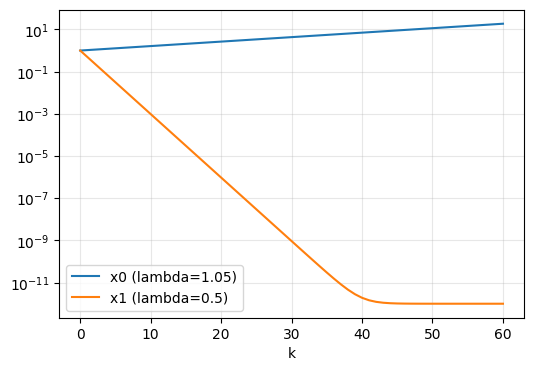

In [17]:
A = np.array([[1.05, 0.0], [0.0, 0.5]])
x = np.array([1.0, 1.0]); traj = [x.copy()]
for _ in range(60):
    x = A @ x; traj.append(x.copy())
traj = np.array(traj)
plt.figure(figsize=(6, 4))
plt.semilogy(np.abs(traj[:, 0]), label="x0 (lambda=1.05)")
plt.semilogy(np.abs(traj[:, 1]) + 1e-12, label="x1 (lambda=0.5)")
plt.xlabel("k"); plt.grid(alpha=0.3, which="both"); plt.legend(); plt.show()

### 演習 6(発展)— べき乗の計算時間: 素朴 vs 対角化

In [18]:
import time
F = np.array([[1.0, 1.0], [1.0, 0.0]])
w, V = np.linalg.eig(F); Vinv = np.linalg.inv(V)

def naive(k):
    M = np.eye(2)
    for _ in range(k):
        M = M @ F
    return M

def via_diag(k):
    return (V @ np.diag(w**k) @ Vinv).real

k = 1000   # keep Fibonacci below float overflow (Fib(1000) ~ 2e208 < 1e308)
t0 = time.perf_counter(); naive(k); t1 = time.perf_counter()
via_diag(k); t2 = time.perf_counter()
print(f"naive: {1e3*(t1-t0):.2f} ms   diagonalization: {1e3*(t2-t1):.2f} ms")
print("agree:", np.allclose(naive(20), via_diag(20)))

naive: 0.48 ms   diagonalization: 0.03 ms
agree: True


## 04 章の解答

### 演習 1 — ノルムと直交ベクトル

$\|v\| = \sqrt{1 + 4 + 4} = 3$。$v=(1,2,2)$ に直交する 2 本を取り、Gram-Schmidt で互いにも直交化。

In [19]:
v = np.array([1.0, 2.0, 2.0])
print("||v|| =", np.linalg.norm(v))
a = np.array([2.0, -1.0, 0.0])          # v . a = 0
b = np.array([0.0, 1.0, -1.0])          # v . b = 0
Q = algebra.gram_schmidt(np.column_stack([a, b]))
print("a.v, b.v =", a @ v, b @ v, " | orthonormalized cols dot =", Q[:, 0] @ Q[:, 1])

||v|| = 3.0
a.v, b.v = 0.0 0.0  | orthonormalized cols dot = -5.551115123125783e-17


### 演習 2 — 直線への射影と直交残差

projection = [3.5 3.5]  residual.a = 0.0


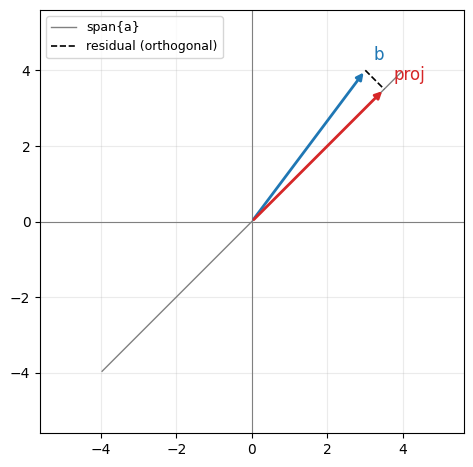

In [20]:
b = np.array([3.0, 4.0]); a = np.array([1.0, 1.0])
p = (a @ b) / (a @ a) * a
print("projection =", p, " residual.a =", (b - p) @ a)
plotting.plot_projection(b, a)
plt.show()

### 演習 3 — 射影行列のべき等性 $P^2 = P$

$P^2 = A(A^\top A)^{-1}A^\top A(A^\top A)^{-1}A^\top = A(A^\top A)^{-1}A^\top = P$(中央の $A^\top A (A^\top A)^{-1} = I$)。

In [21]:
A = rng.standard_normal((6, 2))
P = algebra.projection_matrix(A)
print("||P@P - P|| =", np.linalg.norm(P @ P - P))

||P@P - P|| = 9.33016792379982e-16


### 演習 4 — 最小二乗で直線フィット

In [22]:
x = np.array([0.0, 1, 2]); y = np.array([1.0, 2, 4])
A = np.column_stack([x, np.ones_like(x)])
coef, res = algebra.least_squares(A, y)
# Normal equations by hand:
hand = np.linalg.solve(A.T @ A, A.T @ y)
print("least_squares:", coef, " normal-equation:", hand)

least_squares: [1.5    0.8333]  normal-equation: [1.5    0.8333]


### 演習 5 — 多項式フィットの訓練誤差は次数で単調減少

訓練誤差は次数とともに必ず下がる(自由度が増えるだけ当てはまる)ので、
これでは過学習を検出できない。検証データの誤差を見る必要がある。

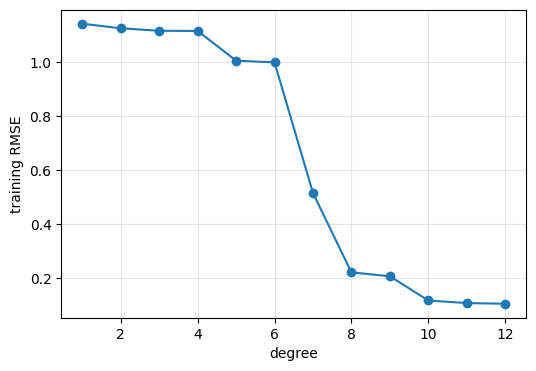

monotonically decreasing: True


In [23]:
xt, yt = datasets.make_noisy_line(n=15, slope=1.0, noise=1.0, seed=5)
yt = yt + 0.8 * np.sin(2.5 * xt)
errs = []
for deg in range(1, 13):
    c, r = algebra.least_squares(np.vander(xt, deg + 1), yt)
    errs.append(np.sqrt(np.mean((np.polyval(c, xt) - yt) ** 2)))
plt.figure(figsize=(6, 4))
plt.plot(range(1, 13), errs, "o-")
plt.xlabel("degree"); plt.ylabel("training RMSE"); plt.grid(alpha=0.3); plt.show()
print("monotonically decreasing:", all(np.diff(errs) <= 1e-9))

### 演習 6(発展)— $\sin(\pi x)$ の多項式近似(格子点最小二乗)

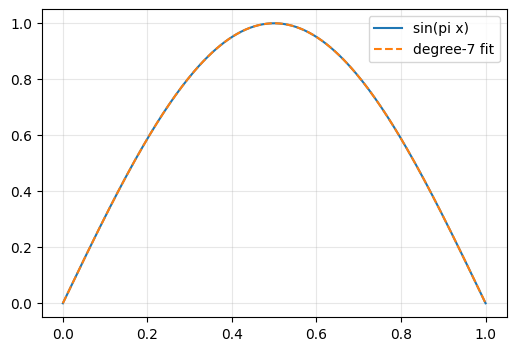

max abs error: 1.4743045028615955e-05


In [24]:
xs = np.linspace(0, 1, 200)
ys = np.sin(np.pi * xs)
c, r = algebra.least_squares(np.vander(xs, 8), ys)
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, label="sin(pi x)")
plt.plot(xs, np.polyval(c, xs), "--", label="degree-7 fit")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("max abs error:", np.abs(np.polyval(c, xs) - ys).max())

## 05 章の解答

### 演習 1 — 特異値は $A^\top A$ の固有値の平方根

In [25]:
A = np.array([[3.0, 0.0], [4.0, 5.0]])
eig = np.sort(np.linalg.eigvalsh(A.T @ A))[::-1]
print("sqrt(eig(A^T A)) =", np.sqrt(eig))
print("np.linalg.svd     =", np.linalg.svd(A, compute_uv=False))

sqrt(eig(A^T A)) = [6.7082 2.2361]
np.linalg.svd     = [6.7082 2.2361]


### 演習 2 — LU 分解の三角性

In [26]:
M = rng.standard_normal((5, 5))
P, L, U = dec.lu(M)
print("L lower-tri:", np.allclose(np.tril(L), L), " U upper-tri:", np.allclose(np.triu(U), U))
print("||P L U - M|| =", np.linalg.norm(P @ L @ U - M))

L lower-tri: True  U upper-tri: True
||P L U - M|| = 2.924231343973887e-16


### 演習 3 — Eckart-Young の Frobenius 誤差

In [27]:
img = datasets.make_test_image(64)
s = np.linalg.svd(img, compute_uv=False)
for k in [2, 5, 20]:
    err = np.linalg.norm(img - dec.svd_lowrank(img, k), "fro")
    tail = np.sqrt((s[k:] ** 2).sum())
    print(f"k={k:>2}: ||A - A_k||_F = {err:.4f}, sqrt(sum tail s^2) = {tail:.4f}")

k= 2: ||A - A_k||_F = 9.1381, sqrt(sum tail s^2) = 9.1381
k= 5: ||A - A_k||_F = 4.9308, sqrt(sum tail s^2) = 4.9308
k=20: ||A - A_k||_F = 0.3365, sqrt(sum tail s^2) = 0.3365


### 演習 4 — PCA 第 1 主成分は長軸を向く

explained variance ratio: [0.97 0.03]


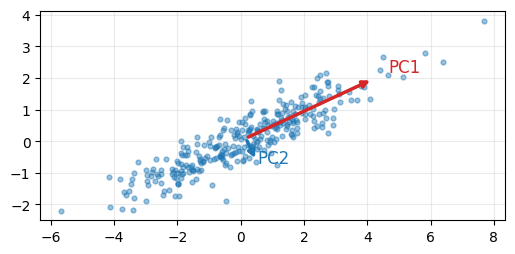

In [28]:
X = datasets.make_correlated_cloud(n=300, cov=((4.0, 1.8), (1.8, 1.0)), seed=0)
res = dec.pca_fit(X)
print("explained variance ratio:", res.explained_variance_ratio.round(3))
plotting.plot_pca_axes(X, res)
plt.show()

### 演習 5 — スケール混在と標準化

片方の列を 100 倍すると、分散の大きい変数が第 1 主成分を独占する。
列ごとに標準化(分散 1)すれば軸の取り方が回復する。

In [29]:
X2 = X.copy(); X2[:, 1] *= 100
print("raw PCA  PC1:", dec.pca_fit(X2).components[0].round(3), "(dominated by col 1)")
Xs = (X2 - X2.mean(0)) / X2.std(0)
print("std PCA  PC1:", dec.pca_fit(Xs).components[0].round(3), "(balanced)")

raw PCA  PC1: [-0.018 -1.   ] (dominated by col 1)
std PCA  PC1: [0.707 0.707] (balanced)


### 演習 6(発展)— 低ランク近似を自力実装

In [30]:
def my_lowrank(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ Vt[:k]

A = rng.standard_normal((10, 8))
print("max |mine - svd_lowrank| =", np.abs(my_lowrank(A, 3) - dec.svd_lowrank(A, 3)).max())

max |mine - svd_lowrank| = 0.0


## 06 章の解答

### 演習 1 — 浮動小数点の等値比較

In [31]:
print("0.1 + 0.2 == 0.3 :", 0.1 + 0.2 == 0.3)
print("abs(diff) < tol  :", abs((0.1 + 0.2) - 0.3) < 1e-12)
print("np.isclose       :", np.isclose(0.1 + 0.2, 0.3))

0.1 + 0.2 == 0.3 : False
abs(diff) < tol  : True
np.isclose       : True


### 演習 2 — 条件数 = $\sigma_\max / \sigma_\min$

In [32]:
A = np.array([[1.0, 1.0], [1.0, 1.0001]])
s = np.linalg.svd(A, compute_uv=False)
print("sigma_max/sigma_min =", s[0] / s[-1], " np.linalg.cond =", np.linalg.cond(A))

sigma_max/sigma_min = 40002.00007491187  np.linalg.cond = 40002.00007491187


### 演習 3 — Hilbert 行列の誤差限界

In [33]:
from scipy.linalg import hilbert
H = hilbert(10)
x_true = np.ones(10); b = H @ x_true
db = 1e-10 * rng.standard_normal(10)
x_pert = np.linalg.solve(H, b + db)
rel_err = np.linalg.norm(x_pert - x_true) / np.linalg.norm(x_true)
bound = np.linalg.cond(H) * np.linalg.norm(db) / np.linalg.norm(b)
print(f"actual rel error = {rel_err:.2e}, bound kappa*||db||/||b|| = {bound:.2e}")

actual rel error = 1.67e+02, bound kappa*||db||/||b|| = 1.01e+03


### 演習 4 — 条件数と勾配降下の収束

In [34]:
for kappa in [10.0, 100.0]:
    A = np.array([[kappa, 0.0], [0.0, 1.0]]); b = np.array([kappa, 1.0])
    path = algebra.gradient_descent_quadratic(A, b, lr=1.9 / kappa, n_iter=200,
                                              x0=np.array([-1.0, 1.0]))
    err = np.linalg.norm(path - np.linalg.solve(A, b), axis=1)
    n_to_conv = int(np.argmax(err < 1e-3)) if (err < 1e-3).any() else len(err)
    print(f"kappa={kappa:>5}: steps to error<1e-3 = {n_to_conv}")

kappa= 10.0: steps to error<1e-3 = 73
kappa=100.0: steps to error<1e-3 = 73


### 演習 5 — CG は n 回以内で収束

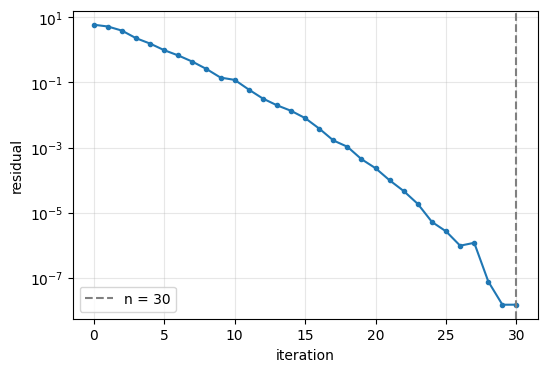

converged in 30 iterations (n = 30)


In [35]:
M = rng.standard_normal((30, 30)); A = M @ M.T + 5 * np.eye(30)
b = rng.standard_normal(30)
x, res = algebra.conjugate_gradient(A, b, tol=1e-12)
plt.figure(figsize=(6, 4))
plt.semilogy(res, "o-", ms=3)
plt.axvline(30, color="gray", ls="--", label="n = 30")
plt.xlabel("iteration"); plt.ylabel("residual"); plt.grid(alpha=0.3, which="both"); plt.legend()
plt.show()
print(f"converged in {len(res) - 1} iterations (n = 30)")

### 演習 6(発展)— 疎行列の CG

In [36]:
import scipy.sparse as sp_sparse
from scipy.sparse.linalg import cg

n = 100_000
diags = [2.1 * np.ones(n), -1 * np.ones(n - 1), -1 * np.ones(n - 1)]
A = sp_sparse.diags(diags, [0, -1, 1], format="csr")
b = rng.standard_normal(n)
x, info = cg(A, b, rtol=1e-8)
print(f"sparse CG on n={n:,}: converged (info={info}), residual = {np.linalg.norm(A @ x - b):.2e}")
print(f"dense would need {n*n*8/1e9:.0f} GB just to store A -> infeasible")

sparse CG on n=100,000: converged (info=0), residual = 2.79e-06
dense would need 80 GB just to store A -> infeasible


## 07 章の解答

### 演習 1 — Markov 連鎖の P^k は定常分布へ

In [37]:
P = np.array([[0.7, 0.2, 0.1], [0.3, 0.4, 0.3], [0.2, 0.4, 0.4]])
pi = algebra.markov_stationary(P)
for k in [1, 2, 5, 20]:
    Pk = np.linalg.matrix_power(P, k)
    print(f"P^{k:>2} row spread (max-min of col means) = {np.ptp(Pk, axis=0).max():.4f}")
print("stationary pi =", pi)

P^ 1 row spread (max-min of col means) = 0.5000
P^ 2 row spread (max-min of col means) = 0.2300
P^ 5 row spread (max-min of col means) = 0.0218
P^20 row spread (max-min of col means) = 0.0000
stationary pi = [0.4615 0.3077 0.2308]


### 演習 2 — PageRank はリンク元の変更が波及する

In [38]:
names, adj = datasets.make_web_graph()
r0 = algebra.page_rank(adj)
adj2 = adj.copy()
f, a, b = names.index("F"), names.index("A"), names.index("B")
adj2[f, a] = 0; adj2[f, b] = 1          # rewrite F->A to F->B
r1 = algebra.page_rank(adj2)
for i, nm in enumerate(names):
    print(f"{nm}: {r0[i]:.3f} -> {r1[i]:.3f}  ({r1[i]-r0[i]:+.3f})")
print("F's outlink change shifts rank mass downstream (A loses, B gains, and it propagates).")

A: 0.302 -> 0.283  (-0.019)
B: 0.156 -> 0.175  (+0.019)
C: 0.223 -> 0.223  (+0.000)
D: 0.123 -> 0.123  (+0.000)
E: 0.080 -> 0.080  (+0.000)
F: 0.062 -> 0.062  (+0.000)
G: 0.054 -> 0.054  (+0.000)
F's outlink change shifts rank mass downstream (A loses, B gains, and it propagates).


### 演習 3 — ラプラシアンの固有値 0 の重複度 = 連結成分数

In [39]:
adj, labels = datasets.make_two_cluster_graph(n_per=8, p_in=0.8, p_out=0.0, seed=3)
L = np.diag(adj.sum(1)) - adj
eigs = np.linalg.eigvalsh(L)
n_zero = int(np.sum(eigs < 1e-9))
print(f"number of ~zero eigenvalues = {n_zero}  (graph has 2 disconnected communities)")

number of ~zero eigenvalues = 2  (graph has 2 disconnected communities)


### 演習 4 — 2 資産ポートフォリオの分散と相関

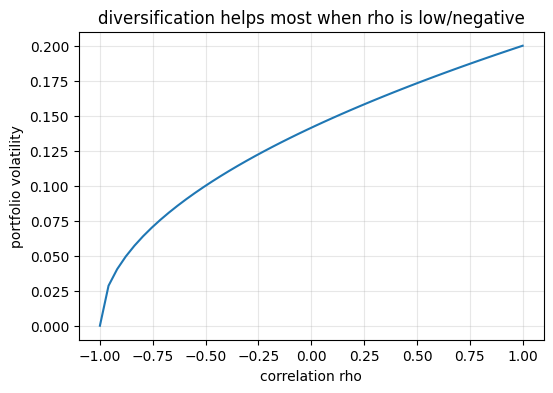

In [40]:
sig = 0.2
rhos = np.linspace(-1, 1, 50)
var = 0.25 * sig**2 + 0.25 * sig**2 + 2 * 0.5 * 0.5 * rhos * sig * sig
plt.figure(figsize=(6, 4))
plt.plot(rhos, np.sqrt(var))
plt.xlabel("correlation rho"); plt.ylabel("portfolio volatility")
plt.title("diversification helps most when rho is low/negative"); plt.grid(alpha=0.3)
plt.show()

### 演習 5 — 金利カーブ PCA を「水準」で行う

水準データは強い自己相関(ほぼ単位根)を持つため、第 1 主成分(Level)が分散の
ほぼ全てを説明してしまい、Slope/Curvature の分離が見えにくくなる。実務は変化分で行う理由。

In [41]:
mats, curves = datasets.make_yield_curves(n_days=500, seed=42)
res_level = dec.pca_fit(curves.to_numpy(), n_components=3)
res_change = dec.pca_fit(np.diff(curves.to_numpy(), axis=0), n_components=3)
print("levels   explained ratio:", res_level.explained_variance_ratio[:3].round(3))
print("changes  explained ratio:", res_change.explained_variance_ratio[:3].round(3))

levels   explained ratio: [0.985 0.013 0.001]
changes  explained ratio: [0.973 0.018 0.002]


### 演習 6(発展)— 量子ゲート $R_\theta$ の測定確率

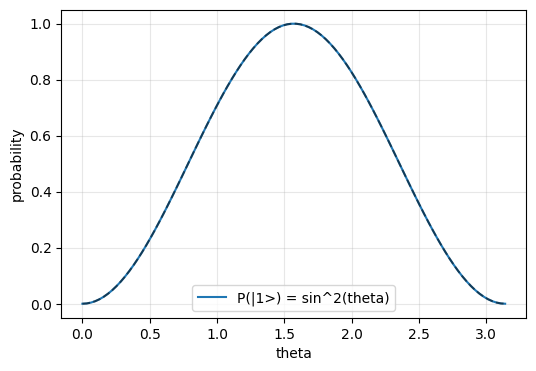

In [42]:
thetas = np.linspace(0, np.pi, 100)
ket0 = np.array([1.0, 0.0])
p1 = []
for th in thetas:
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    psi = R @ ket0
    p1.append(abs(psi[1]) ** 2)        # P(measure |1>)
plt.figure(figsize=(6, 4))
plt.plot(thetas, p1, label="P(|1>) = sin^2(theta)")
plt.plot(thetas, np.sin(thetas) ** 2, "k--", alpha=0.5)
plt.xlabel("theta"); plt.ylabel("probability"); plt.legend(); plt.grid(alpha=0.3)
plt.show()